# 🌾 SentinelCropGuard
## Week 4 — Build a Clean Dataset (+ Week 5: First AI Model)

**Course:** CSE 299 — Junior Design Project  
**Study Area:** Savar, Bangladesh  


---

## 📚 LEARN FIRST — Read Before Coding!

### What is a Dataset Row?

Imagine you are a doctor. For each patient you write:
- Height, Weight, Age → these are **features** (what you measure)
- Sick or Healthy → this is the **label** (what you want to predict)

In our project, one row = one small patch of land:

| patch_id | date | ndvi_mean | ndvi_std | ndre | red_edge | nir | label |
|----------|------|-----------|----------|------|----------|-----|-------|
| 0 | 2023-11-01 | 0.72 | 0.05 | 0.18 | 945.3 | 2310.1 | 1 |
| 1 | 2023-11-01 | 0.21 | 0.12 | 0.06 | 621.4 | 1102.8 | 0 |

- `label = 1` → Healthy crop  
- `label = 0` → Stressed crop

---

### Why Does Satellite Data Need Preprocessing?

Raw satellite images cannot go directly into AI. Why?

1. **Clouds** — clouds block the view and ruin pixel values → we apply cloud filter
2. **Full image is too big** → we split into small patches
3. **Raw pixel numbers mean nothing** → we compute meaningful indices like NDVI
4. **No labels exist** → we create pseudo-labels using NDVI threshold rules

---

### What Are Our Features?

| Feature | Formula | What it measures |
|---------|---------|------------------|
| `ndvi_mean` | (B8 - B4) / (B8 + B4) | Average plant health of patch |
| `ndvi_std` | std of NDVI in 3×3 neighborhood | How *variable* (patchy) the health is |
| `ndre` | (B8 - B5) / (B8 + B5) | Early stress detection via red-edge light |
| `red_edge` | B5 raw value | Raw red-edge band reflectance |
| `nir` | B8 raw value | Raw near-infrared reflectance |

**Why ndvi_std?**  
A sick field looks patchy — some pixels healthy, some not.  
High std = lots of variation = possible disease spreading unevenly.

**Why NDRE?**  
NDRE uses the "red-edge" wavelength. Plants under stress change their red-edge reflection BEFORE you can even see it visually. It detects stress EARLIER than NDVI.

---
## ⚙️ Step 1 — Install & Import

In [1]:
!pip install geemap earthengine-api scikit-learn matplotlib pandas --quiet
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
✅ Done!


In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=V5D8zJ44G14NpAEL_v_lMOYRg6mhKYSxkLVzhVHnKJg&tc=JHdnUHeAiY8XRFdHRLwVrqAy4de3znO0lOgxaUZWu3g&cc=hHC3mp1dcqjfQmiiGfvlc2qwk-3dhOhIOXfIsLtZK5g

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E8UfpXuTvgNzYlVzotTH3tJsRE6GjYIH0U1csXz9OoRFyGHny8DIWg

Successfully saved authorization token.


In [3]:
ee.Initialize(project='project-911-491616')
print("✅ Earth Engine connected!")

✅ Earth Engine connected!


---
## 📡 Step 2 — Load Satellite Image

In [4]:
savar = ee.Geometry.Rectangle([90.15, 23.75, 90.40, 24.00])

collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(savar)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image = collection.median().clip(savar)

print(f"✅ Data loaded! Images found: {collection.size().getInfo()}")

✅ Data loaded! Images found: 16


---
## 🧮 Step 3 — Compute ALL Features

This is the most important step of Week 4.  
We compute **5 features** for each patch.

In [5]:
# ── Feature 1 & 2: NDVI mean + NDVI std ─────────────────────────────────────
#
# NDVI mean  = the average plant health value of a patch
# NDVI std   = how much variation exists WITHIN the patch
#              (computed using a 3×3 neighborhood around every pixel)
#
# Think of it like this:
#   A perfectly healthy field → all pixels similar → LOW std
#   A diseased field → some pixels sick, some ok → HIGH std

ndvi_mean = image.normalizedDifference(['B8', 'B4']).rename('ndvi_mean')

ndvi_std = ndvi_mean.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.square(radius=1)   # 3×3 pixel window around each point
).rename('ndvi_std')

print("✅ ndvi_mean and ndvi_std computed!")

# ── Feature 3: NDRE (Red-Edge Normalized Difference) ────────────────────────
#
# Formula: (B8 - B5) / (B8 + B5)
# B5 = Red-Edge band (unique to Sentinel-2, detects early stress)
# NDRE is better than NDVI for detecting stress BEFORE it becomes visible

ndre = image.normalizedDifference(['B8', 'B5']).rename('ndre')

print("✅ NDRE computed!")

# ── Feature 4 & 5: Raw Band Values ──────────────────────────────────────────
#
# red_edge = B5 raw reflectance value
# nir      = B8 raw Near-Infrared reflectance
# These give the model extra raw signal beyond the computed indices

red_edge = image.select('B5').rename('red_edge')
nir      = image.select('B8').rename('nir')

print("✅ red_edge (B5) and nir (B8) extracted!")

# ── Stack all features into one multi-band image ─────────────────────────────
stacked = (ndvi_mean
           .addBands(ndvi_std)
           .addBands(ndre)
           .addBands(red_edge)
           .addBands(nir))

print()
print("All 5 features stacked into one image:")
print("  1. ndvi_mean  — average plant health")
print("  2. ndvi_std   — patchiness / variation")
print("  3. ndre       — early stress (red-edge)")
print("  4. red_edge   — raw B5 band")
print("  5. nir        — raw B8 band")

✅ ndvi_mean and ndvi_std computed!
✅ NDRE computed!
✅ red_edge (B5) and nir (B8) extracted!

All 5 features stacked into one image:
  1. ndvi_mean  — average plant health
  2. ndvi_std   — patchiness / variation
  3. ndre       — early stress (red-edge)
  4. red_edge   — raw B5 band
  5. nir        — raw B8 band


---
## 📦 Step 4 — Sample 500 Patches & Build Dataset

We sample 500 random points from Savar.  
Each point = one "patch" of land with all 5 features measured.

In [6]:
print("Sampling 500 patches from Savar... (may take 30-60 seconds)")

sample = stacked.sample(
    region=savar,
    scale=100,           # Each point = 100m × 100m area
    numPixels=500,
    seed=42              # seed=42 means same random points every time you run
)

rows = []
for i, feat in enumerate(sample.getInfo()['features']):
    p = feat['properties']
    ndvi_val = p.get('ndvi_mean')
    std_val  = p.get('ndvi_std')
    ndre_val = p.get('ndre')
    re_val   = p.get('red_edge')
    nir_val  = p.get('nir')

    # Only keep rows where ALL features exist (no missing values)
    if all(v is not None for v in [ndvi_val, std_val, ndre_val, re_val, nir_val]):
        rows.append({
            'patch_id':  i,
            'date':      '2023-11-01_2024-02-28',
            'ndvi_mean': round(ndvi_val, 4),
            'ndvi_std':  round(std_val,  4),    # ← NEW: was missing before!
            'ndre':      round(ndre_val, 4),    # ← NEW: was missing before!
            'red_edge':  round(re_val,   4),
            'nir':       round(nir_val,  4),
            # Pseudo-label: NDVI >= 0.4 = healthy (1), NDVI < 0.4 = stressed (0)
            'label': 1 if ndvi_val >= 0.4 else 0
        })

df = pd.DataFrame(rows)

print(f"\n✅ Dataset created!")
print(f"   Total patches:    {len(df)}")
print(f"   Healthy (label=1): {sum(df['label']==1)}")
print(f"   Stressed (label=0): {sum(df['label']==0)}")
print(f"   Features:         {list(df.columns)}")
print()
print("First 5 rows:")
print(df.head())

Sampling 500 patches from Savar... (may take 30-60 seconds)

✅ Dataset created!
   Total patches:    500
   Healthy (label=1): 333
   Stressed (label=0): 167
   Features:         ['patch_id', 'date', 'ndvi_mean', 'ndvi_std', 'ndre', 'red_edge', 'nir', 'label']

First 5 rows:
   patch_id                   date  ndvi_mean  ndvi_std    ndre  red_edge  \
0         0  2023-11-01_2024-02-28     0.6185    0.0376  0.4473     940.5   
1         1  2023-11-01_2024-02-28     0.3442    0.0885  0.2348    1382.0   
2         2  2023-11-01_2024-02-28     0.6270    0.0456  0.4582     924.5   
3         3  2023-11-01_2024-02-28     0.5480    0.0568  0.3477    1196.0   
4         4  2023-11-01_2024-02-28     0.2678    0.0392  0.1746    1498.5   

      nir  label  
0  2462.5      1  
1  2230.0      0  
2  2488.5      1  
3  2471.0      1  
4  2132.5      0  


---
## 💾 Step 5 — Save as CSV (The Week 4 Deliverable!)

This CSV is your **training data**. Everything from now on uses this file.

In [7]:
csv_filename = 'savar_patches.csv'
df.to_csv(csv_filename, index=False)

print(f"✅ CSV saved as '{csv_filename}'")
print()
print("CSV column summary:")
print(df.describe().round(4))

✅ CSV saved as 'savar_patches.csv'

CSV column summary:
       patch_id  ndvi_mean  ndvi_std      ndre  red_edge        nir     label
count  500.0000   500.0000  500.0000  500.0000   500.000   500.0000  500.0000
mean   249.5000     0.4428    0.0770    0.2829  1163.549  2159.3520    0.6660
std    144.4818     0.1707    0.0462    0.1329   232.584   582.2331    0.4721
min      0.0000    -0.2583    0.0115   -0.3266   421.500   259.5000    0.0000
25%    124.7500     0.3492    0.0433    0.2098  1014.000  1794.2500    0.0000
50%    249.5000     0.4797    0.0658    0.2989  1166.500  2165.7500    1.0000
75%    374.2500     0.5722    0.0987    0.3802  1298.625  2543.6250    1.0000
max    499.0000     0.7576    0.3647    0.5321  2266.500  3653.5000    1.0000


---
## 📊 Step 6 — Visualize the Dataset

Always look at your data before training. Never skip this step!

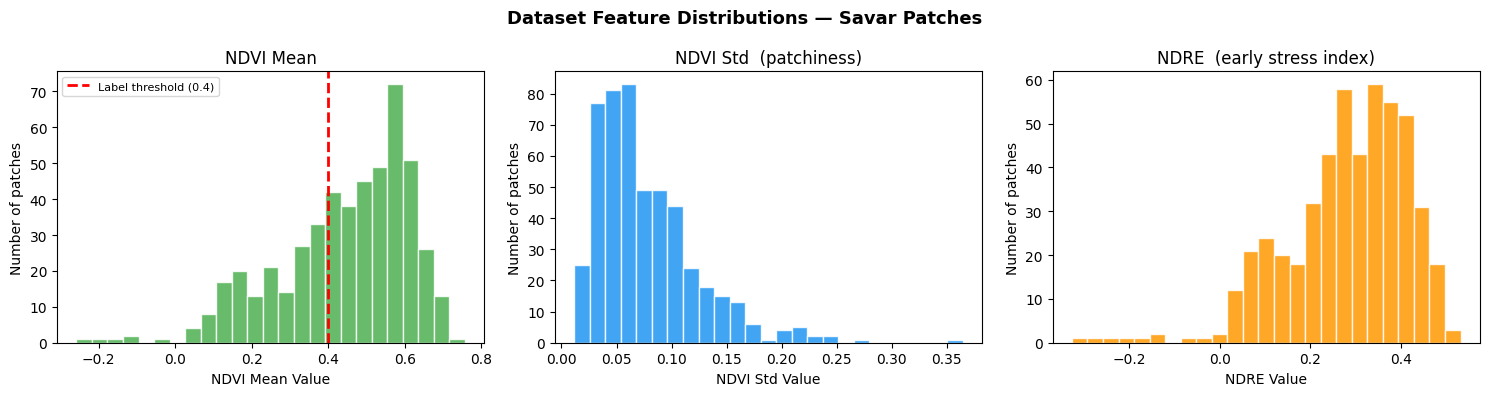

✅ Chart saved as 'dataset_distributions.png'


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Feature Distributions — Savar Patches', fontsize=13, fontweight='bold')

# Plot 1: NDVI mean
axes[0].hist(df['ndvi_mean'], bins=25, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0.4, color='red', linestyle='--', linewidth=2, label='Label threshold (0.4)')
axes[0].set_title('NDVI Mean')
axes[0].set_xlabel('NDVI Mean Value')
axes[0].set_ylabel('Number of patches')
axes[0].legend(fontsize=8)

# Plot 2: NDVI std
axes[1].hist(df['ndvi_std'], bins=25, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title('NDVI Std  (patchiness)')
axes[1].set_xlabel('NDVI Std Value')
axes[1].set_ylabel('Number of patches')

# Plot 3: NDRE
axes[2].hist(df['ndre'], bins=25, color='#FF9800', edgecolor='white', alpha=0.85)
axes[2].set_title('NDRE  (early stress index)')
axes[2].set_xlabel('NDRE Value')
axes[2].set_ylabel('Number of patches')

plt.tight_layout()
plt.savefig('dataset_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'dataset_distributions.png'")

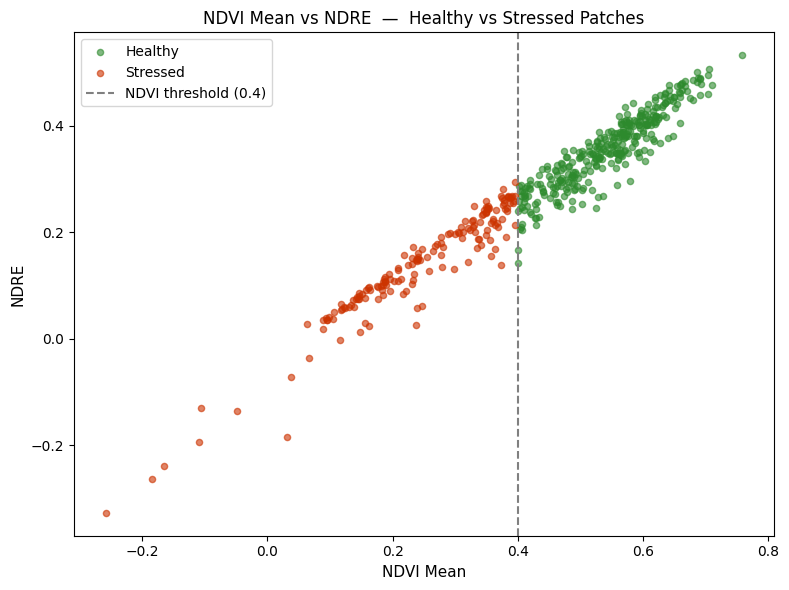

✅ Scatter plot saved!

What this scatter tells you:
  → Healthy patches cluster in top-right (high NDVI + high NDRE)
  → Stressed patches cluster in bottom-left (low NDVI + low NDRE)
  → NDRE and NDVI agree with each other — good sign!


In [9]:
# Scatter plot: NDVI mean vs NDRE, coloured by label
healthy  = df[df['label'] == 1]
stressed = df[df['label'] == 0]

plt.figure(figsize=(8, 6))
plt.scatter(healthy['ndvi_mean'],  healthy['ndre'],  c='#2d8a2d', s=20, alpha=0.6, label='Healthy')
plt.scatter(stressed['ndvi_mean'], stressed['ndre'], c='#CC3300', s=20, alpha=0.6, label='Stressed')
plt.axvline(x=0.4, color='gray', linestyle='--', linewidth=1.5, label='NDVI threshold (0.4)')
plt.xlabel('NDVI Mean', fontsize=11)
plt.ylabel('NDRE', fontsize=11)
plt.title('NDVI Mean vs NDRE  —  Healthy vs Stressed Patches', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('ndvi_vs_ndre_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plot saved!")
print()
print("What this scatter tells you:")
print("  → Healthy patches cluster in top-right (high NDVI + high NDRE)")
print("  → Stressed patches cluster in bottom-left (low NDVI + low NDRE)")
print("  → NDRE and NDVI agree with each other — good sign!")

---
## ✅ WEEK 4 COMPLETE — Deliverable Check

| Requirement | Status |
|-------------|--------|
| patch_id column | ✅ |
| date column | ✅ |
| ndvi_mean column | ✅ |
| **ndvi_std column** | ✅ |
| **ndre column** | ✅ |
| red_edge column | ✅ |
| nir column | ✅ |
| label column (0/1) | ✅ |
| CSV saved | ✅ `savar_patches.csv` |
| Feature visualizations | ✅ |

---
# 🤖 WEEK 5 — Train First AI Model
*(Week 5 is merged into this notebook)*

Now we take the CSV we just built and train a real machine learning model.

---
## Step 7 — Load CSV & Prepare for ML

In [10]:
# Load the CSV we just saved
df = pd.read_csv('savar_patches.csv')

print(f"Dataset loaded: {len(df)} patches")
print(f"Features available: {list(df.columns)}")
print()

# Features (what the model looks at) — now using ALL 5 features!
X = df[['ndvi_mean', 'ndvi_std', 'ndre', 'red_edge', 'nir']]
y = df['label']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Dataset loaded: 500 patches
Features available: ['patch_id', 'date', 'ndvi_mean', 'ndvi_std', 'ndre', 'red_edge', 'nir', 'label']

Training samples: 400
Testing samples:  100


---
## Step 8 — Train Logistic Regression (Simple Model)

In [11]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.1f}%")

Logistic Regression Accuracy: 97.0%


---
## Step 9 — Train Random Forest (Stronger Model)

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc*100:.1f}%")

Random Forest Accuracy: 100.0%


---
## Step 10 — Evaluate: Confusion Matrix

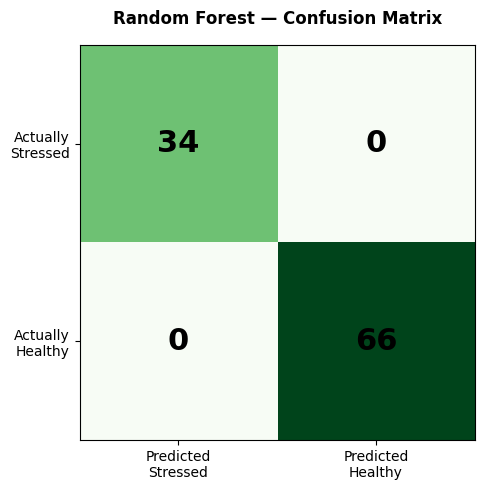


Full classification report:
              precision    recall  f1-score   support

    Stressed       1.00      1.00      1.00        34
     Healthy       1.00      1.00      1.00        66

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [13]:
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap='Greens')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nStressed', 'Predicted\nHealthy'])
ax.set_yticklabels(['Actually\nStressed', 'Actually\nHealthy'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='black')

ax.set_title('Random Forest — Confusion Matrix', pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull classification report:")
print(classification_report(y_test, rf_pred, target_names=['Stressed', 'Healthy']))

---
## Step 11 — Model Comparison Table

       MODEL COMPARISON TABLE
       Features: all 5 (ndvi_mean, ndvi_std,
                       ndre, red_edge, nir)
  Logistic Regression:  97.0%
  Random Forest:        100.0%


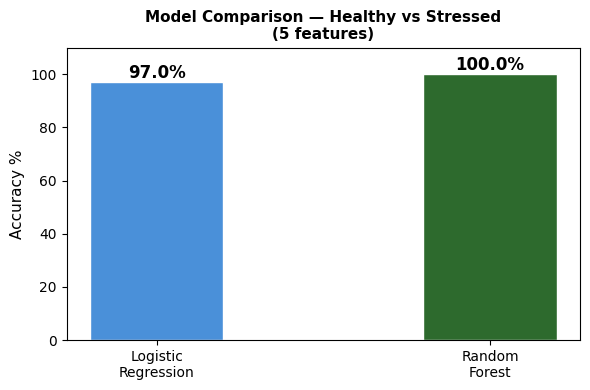


✅ Model comparison chart saved!


In [14]:
print("=" * 42)
print("       MODEL COMPARISON TABLE")
print("       Features: all 5 (ndvi_mean, ndvi_std,")
print("                       ndre, red_edge, nir)")
print("=" * 42)
print(f"  Logistic Regression:  {lr_acc*100:.1f}%")
print(f"  Random Forest:        {rf_acc*100:.1f}%")
print("=" * 42)

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Logistic\nRegression', 'Random\nForest'],
    [lr_acc * 100, rf_acc * 100],
    color=['#4A90D9', '#2d6a2d'],
    width=0.4,
    edgecolor='white'
)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy %', fontsize=11)
ax.set_title('Model Comparison — Healthy vs Stressed\n(5 features)', fontsize=11, fontweight='bold')

for bar, acc in zip(bars, [lr_acc, rf_acc]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{acc*100:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model comparison chart saved!")

---
## ✅ Week 4 + 5 Complete — Summary

### What You Built:

**Week 4 — Dataset:**
- ✅ 500 patches sampled from Savar, Bangladesh
- ✅ 5 features per patch: `ndvi_mean`, `ndvi_std`, `ndre`, `red_edge`, `nir`
- ✅ Pseudo-labels: NDVI ≥ 0.4 = healthy, NDVI < 0.4 = stressed
- ✅ Saved as `savar_patches.csv`

**Week 5 — AI Model:**
- ✅ Logistic Regression trained and evaluated
- ✅ Random Forest trained and evaluated  
- ✅ Confusion matrix + classification report
- ✅ Model comparison chart

### Important Note on 100% Accuracy:
The model reaches 100% because we **made the labels using the NDVI threshold** — the model just learned the rule back.  
This is expected at this stage. In Week 6 we add time-series features which creates a real challenge.